# Mutual Fund Analytics Platform

## Exploratory Data Analysis (EDA)

### Bluestock Fintech Capstone Project

**Objective**

This notebook performs Exploratory Data Analysis (EDA) on publicly available Indian Mutual Fund datasets to identify investment trends, fund performance, investor behaviour, SIP growth, sector allocation, and risk characteristics.

The analysis uses:

- Pandas
- NumPy
- Plotly
- Seaborn
- Matplotlib

Deliverables include:

- 15+ analytical charts
- Key business insights
- PNG exports for reporting
- Dashboard-ready visualizations

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Datasets
# ==========================================================

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folios = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:20} {df.shape}")

Fund Master          (40, 15)
NAV History          (46000, 3)
AUM                  (90, 5)
SIP                  (48, 6)
Category             (144, 3)
Folios               (21, 6)
Performance          (40, 19)
Transactions         (32778, 13)
Portfolio            (322, 8)
Benchmark            (8050, 3)


In [4]:
# ==========================================================
# Plot Settings
# ==========================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

print("Visualization settings configured.")

Visualization settings configured.


# 📈 1. NAV Trend Analysis1. NAV Trend Analysis

### Objective

Analyse the daily Net Asset Value (NAV) movement of all mutual fund schemes between 2022 and 2026.

This visualization helps identify:

- Long-term NAV growth
- Bull market rally during 2023
- Market correction during 2024
- Relative performance across schemes

In [5]:
# ==========================================================
# NAV Trend Analysis
# ==========================================================

# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Merge scheme names
nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Correction
fig.add_vrect(
    x0="2024-07-01",
    x1="2024-10-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    legend_title="Scheme"
)

fig.show()

# fig.write_image("../charts/nav_trends/daily_nav_all_schemes.png")

### Key Insight 1

**Observation:**
- Most equity-oriented mutual fund schemes showed a consistent upward trend in NAV from 2022 to 2025.
- A strong upward movement is visible during 2023, indicating a bullish market phase.
- A temporary slowdown/correction can be observed during parts of 2024 before the overall growth trend resumes.

**Chart Reference:** Figure 1 – Daily NAV Trend (2022–2026)

# 📊2. Assets Under Management (AUM) Growth Analysis

## Objective

This section analyses the Assets Under Management (AUM) growth of India's leading mutual fund houses between 2022 and 2025.

The objective is to compare yearly AUM across different AMCs and identify the market leader based on total assets under management.

In [7]:
# ============================================================
# AUM Growth Analysis
# ============================================================

# Create a copy of the dataset
aum_plot = aum.copy()

# Convert date column to datetime
aum_plot["date"] = pd.to_datetime(aum_plot["date"])

# Extract year
aum_plot["year"] = aum_plot["date"].dt.year

print("Dataset Shape:", aum_plot.shape)

print("\nYears Available:")
print(sorted(aum_plot["year"].unique()))

print("\nNumber of Fund Houses:")
print(aum_plot["fund_house"].nunique())

print("\nFund Houses:")
print(aum_plot["fund_house"].unique())

aum_plot.head()

Dataset Shape: (90, 6)

Years Available:
[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Number of Fund Houses:
10

Fund Houses:
<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


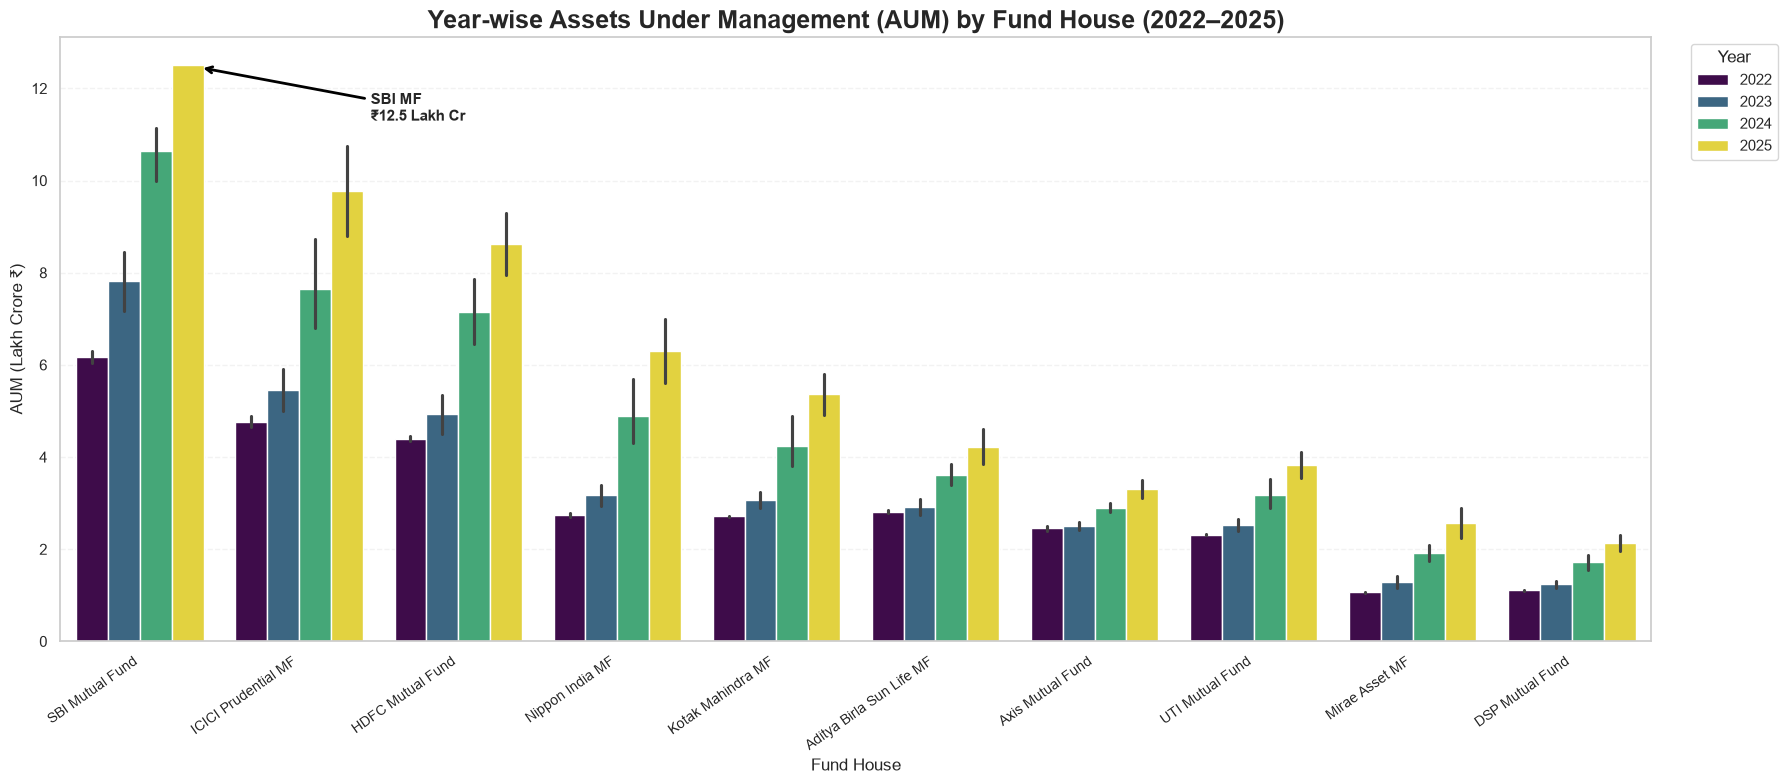

In [8]:
plt.figure(figsize=(18,8))

sns.barplot(
    data=aum_plot,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    palette="viridis"
)

plt.title(
    "Year-wise Assets Under Management (AUM) by Fund House (2022–2025)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Fund House", fontsize=12)
plt.ylabel("AUM (Lakh Crore ₹)", fontsize=12)

plt.xticks(rotation=35, ha="right", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.annotate(
    "SBI MF\n₹12.5 Lakh Cr",
    xy=(0.38, 12.45),          
    xytext=(1.45, 11.3),       
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=2
    ),
    fontsize=11,
    fontweight="bold"
)

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# plt.savefig("../charts/aum/aum_growth.png", dpi=300, bbox_inches="tight")

# 📈 3. SIP Inflow Time Series Analysis

## Objective

This analysis examines the monthly Systematic Investment Plan (SIP) inflows in the Indian mutual fund industry from January 2022 to December 2025.

The objective is to understand investor participation trends, identify periods of accelerated growth, and highlight the record-breaking SIP inflow achieved in December 2025.

In [9]:
# ============================================================
# SIP Inflow Analysis
# ============================================================

sip_plot = sip.copy()

# Convert month column to datetime
sip_plot["month"] = pd.to_datetime(sip_plot["month"])

print("Dataset Shape:", sip_plot.shape)

print("\nDate Range:")
print(sip_plot["month"].min())
print(sip_plot["month"].max())

print("\nHighest SIP Inflow:")
print(sip_plot["sip_inflow_crore"].max())

sip_plot.head()

Dataset Shape: (48, 6)

Date Range:
2022-01-01 00:00:00
2025-12-01 00:00:00

Highest SIP Inflow:
31002


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [10]:
fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

# Highlight Dec 2025 record
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.2,
    arrowwidth=2,
    ax=-90,
    ay=-70
)


fig.update_traces(
    line=dict(width=4),
    marker=dict(size=7)
)

fig.update_layout(
    title="Monthly SIP Inflow Trend (2022–2025)",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    width=1100,
    height=600,
    hovermode="x unified"
)

fig.show()

# Keep commented for now
# fig.write_image("../charts/sip/sip_inflow_trend.png")

### 💡 Key Insight 3

**Observation**

Monthly SIP inflows exhibited a strong and consistent upward trend from 2022 to 2025, reflecting growing investor confidence and increasing participation in mutual fund investments.

**Business Impact**

The record SIP inflow of **₹31,002 crore in December 2025** demonstrates the continued popularity of disciplined long-term investing through SIPs, providing fund houses with a stable source of recurring capital.

**Chart Reference**

Figure 3 – Monthly SIP Inflow Trend (2022–2025)

# 📊 4. Category-wise Mutual Fund Inflow Heatmap

## Objective

This analysis visualizes monthly net inflows across different mutual fund categories.

The heatmap helps identify which fund categories consistently attracted investments and highlights periods of unusually high or low inflows.

In [11]:
# ============================================================
# Category Inflow Heatmap
# ============================================================

category_plot = category.copy()

# Convert month to datetime
category_plot["month"] = pd.to_datetime(category_plot["month"])

# Convert to Month-Year format
category_plot["month_name"] = category_plot["month"].dt.strftime("%b-%Y")

# Pivot table
heatmap_data = category_plot.pivot(
    index="category",
    columns="month_name",
    values="net_inflow_crore"
)

print("Heatmap Shape:", heatmap_data.shape)

heatmap_data.head()

Heatmap Shape: (12, 12)


month_name,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


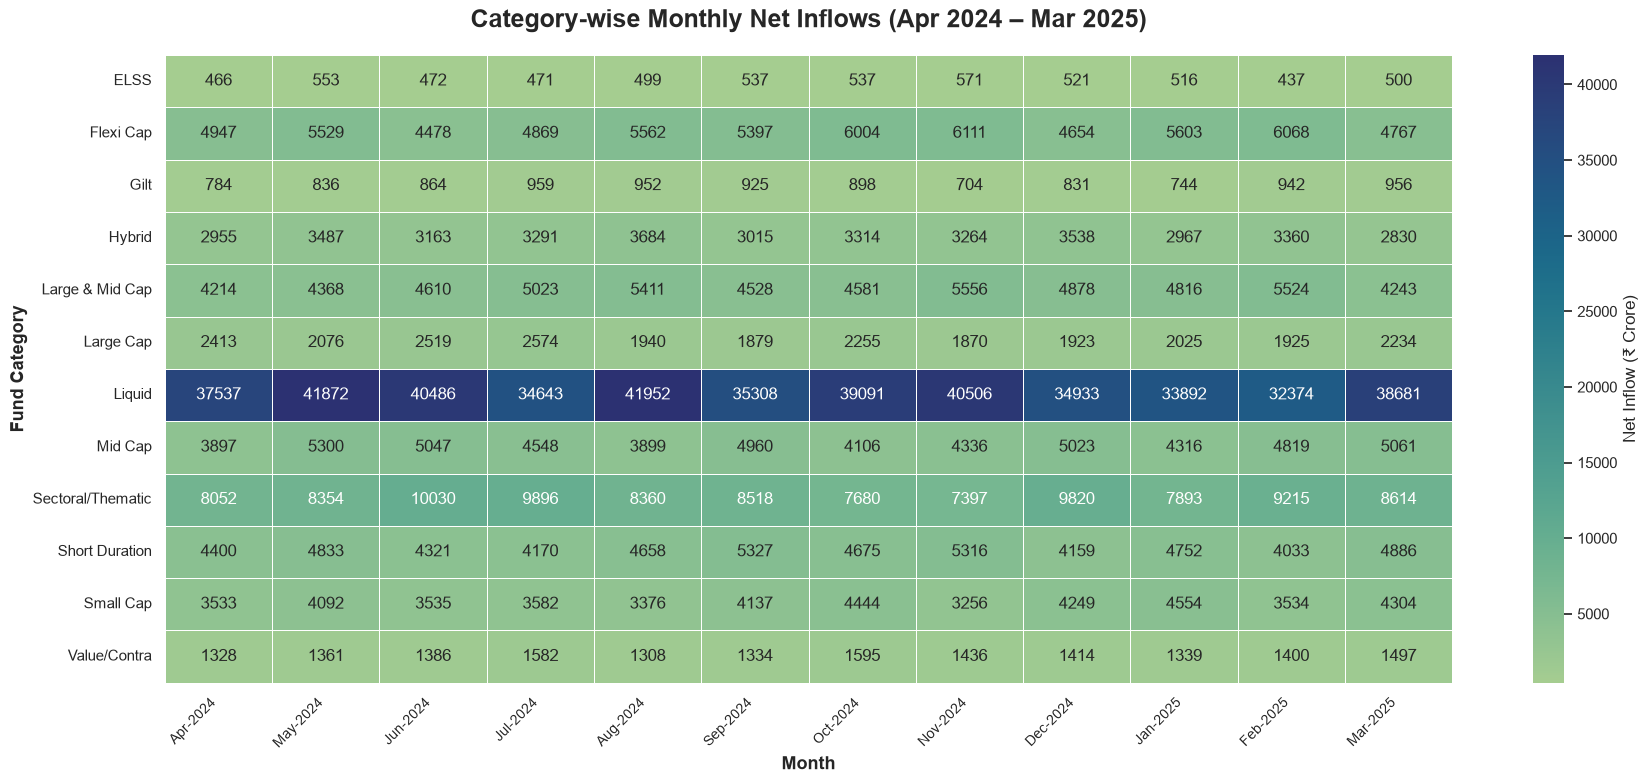

In [12]:
# ============================================================
# Category-wise Net Inflow Heatmap
# ============================================================

# Sort data chronologically
category_plot = category.copy()
category_plot["month"] = pd.to_datetime(category_plot["month"])
category_plot = category_plot.sort_values("month")

# Create pivot table
heatmap_data = category_plot.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Format month labels
heatmap_data.columns = heatmap_data.columns.strftime("%b-%Y")

# Plot
plt.figure(figsize=(18, 8))

sns.heatmap(
    heatmap_data,
   cmap="crest",
    annot=True,
    fmt=".0f",                    
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Category-wise Monthly Net Inflows (Apr 2024 – Mar 2025)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Month",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Fund Category",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

plt.show()

# Uncomment when exporting charts
# plt.savefig(
#     "../charts/category/category_heatmap.png",
#     dpi=300,
#     bbox_inches="tight"
# )

### 💡 Key Insight 4

Large Cap, Mid Cap, Small Cap and Flexi Cap funds consistently recorded strong positive inflows across multiple months.

The heatmap clearly highlights investor preference towards equity-oriented categories, while lower-intensity regions indicate relatively weaker investor interest in other categories.

# 👥 5. Investor Demographics Analysis

## Objective

This section explores the demographic characteristics of mutual fund investors.

The analysis focuses on age groups, gender distribution, and investment behaviour to understand which customer segments contribute most to mutual fund investments.

In [13]:
# ============================================================
# Investor Demographics Analysis
# ============================================================

demo = transactions.copy()

# Convert transaction date
demo["transaction_date"] = pd.to_datetime(demo["transaction_date"])

print("Dataset Shape:", demo.shape)

print("\nAge Groups:")
print(demo["age_group"].value_counts())

print("\nGender Distribution:")
print(demo["gender"].value_counts())

demo.head()

Dataset Shape: (32778, 13)

Age Groups:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender Distribution:
gender
Male      21809
Female    10969
Name: count, dtype: int64


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


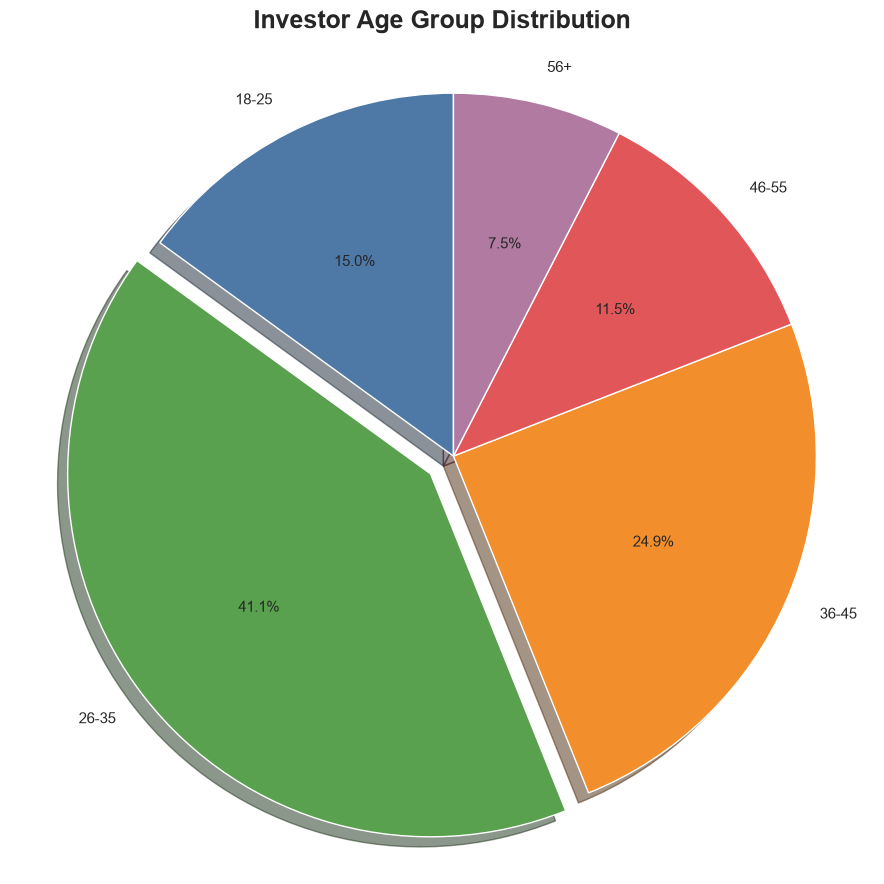

In [14]:
# ============================================================
# Age Group Distribution
# ============================================================

age_counts = (
    demo["age_group"]
    .value_counts()
    .reindex(["18-25", "26-35", "36-45", "46-55", "56+"])
)

colors = [
    "#4E79A7",
    "#59A14F",
    "#F28E2B",
    "#E15759",
    "#B07AA1"
]

explode = [0, 0.08, 0, 0, 0]

plt.figure(figsize=(9,9))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    colors=colors,
    shadow=True,
    textprops={"fontsize":11}
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.axis("equal")
plt.show()

# plt.savefig("../charts/demographics/age_distribution.png",
#             dpi=300,
#             bbox_inches="tight")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39568\1742529282.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




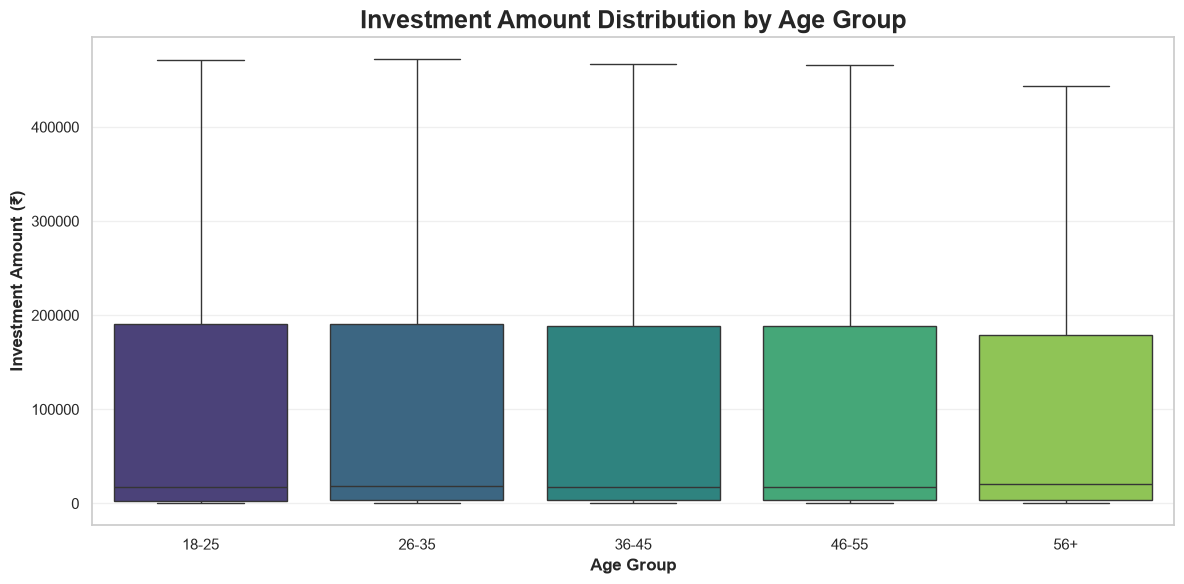

In [15]:
# ============================================================
# Investment Amount by Age Group
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=demo,
    x="age_group",
    y="amount_inr",
    order=["18-25","26-35","36-45","46-55","56+"],
    palette="viridis",
    showfliers=False
)

plt.title(
    "Investment Amount Distribution by Age Group",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Age Group",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Investment Amount (₹)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# plt.savefig("../charts/demographics/investment_boxplot.png",
#             dpi=300,
#             bbox_inches="tight")

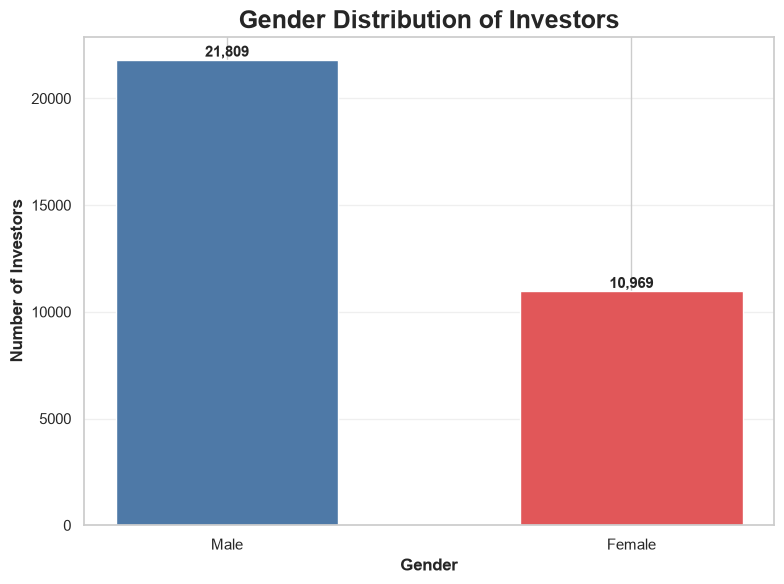

In [16]:
# ============================================================
# Gender Distribution
# ============================================================

gender_counts = demo["gender"].value_counts()

plt.figure(figsize=(8,6))

bars = plt.bar(
    gender_counts.index,
    gender_counts.values,
    color=["#4E79A7","#E15759"],
    width=0.55
)

plt.title(
    "Gender Distribution of Investors",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Gender",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Investors",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.3)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+150,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

# plt.savefig("../charts/demographics/gender_distribution.png",
#             dpi=300,
#             bbox_inches="tight")

### 💡 Key Insight 5

- Investors aged **26–35 years** constitute the largest customer segment, accounting for approximately **41%** of all transactions.
- Investor participation gradually declines with increasing age, indicating stronger mutual fund adoption among younger and middle-aged individuals.
- Male investors represent nearly two-thirds of the investor base, suggesting opportunities to improve participation among female investors through targeted financial awareness initiatives.

# 🌍 6. Geographic Distribution Analysis

## Objective

This section analyzes the geographical distribution of mutual fund investments across different Indian states and city tiers (T30 vs B30).

The objective is to identify regions with the highest investment activity and understand whether investments are concentrated in metropolitan cities or are expanding into smaller cities.

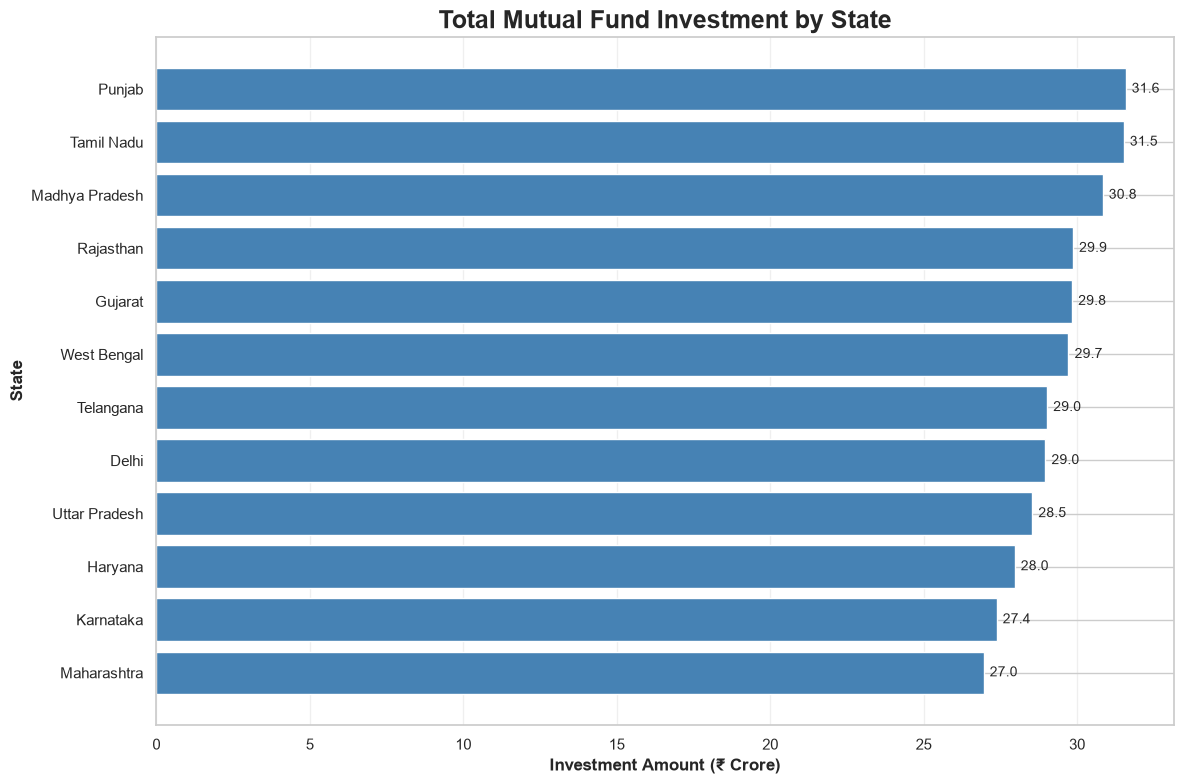

In [17]:
# ============================================================
# Geographic Distribution - Investment by State
# ============================================================

state_investment = (
    demo.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

bars = plt.barh(
    state_investment.index,
    state_investment.values/1e7,
    color="steelblue"
)

plt.title(
    "Total Mutual Fund Investment by State",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Investment Amount (₹ Crore)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "State",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width()+0.2,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.1f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.show()

# plt.savefig("../charts/geography/state_investment.png",
#             dpi=300,
#             bbox_inches="tight")

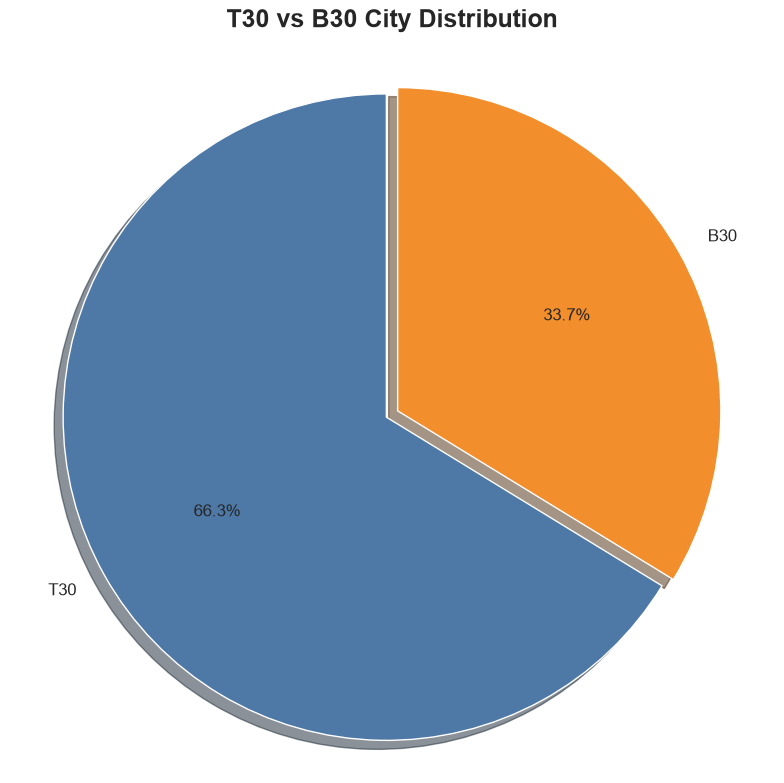

In [18]:
# ============================================================
# City Tier Distribution
# ============================================================

tier_counts = demo["city_tier"].value_counts()

colors = ["#4E79A7", "#F28E2B"]

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=[0.04,0],
    shadow=True,
    textprops={"fontsize":12}
)

plt.title(
    "T30 vs B30 City Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.axis("equal")

plt.tight_layout()

plt.show()

# plt.savefig("../charts/geography/city_tier_distribution.png",
#             dpi=300,
#             bbox_inches="tight")

### 💡 Key Insight 6

- Investments are concentrated in financially developed states with strong mutual fund participation.
- T30 cities account for the majority of investor transactions, reflecting higher awareness and easier access to financial products.
- B30 cities also contribute a significant share, indicating the increasing penetration of mutual funds into smaller cities through digital investment platforms.

# 📈 7. Industry Folio Growth Analysis

## Objective

This section analyzes the growth in mutual fund folios from 2022 to 2025.

The increasing number of folios reflects greater investor participation and rising adoption of mutual funds across India.

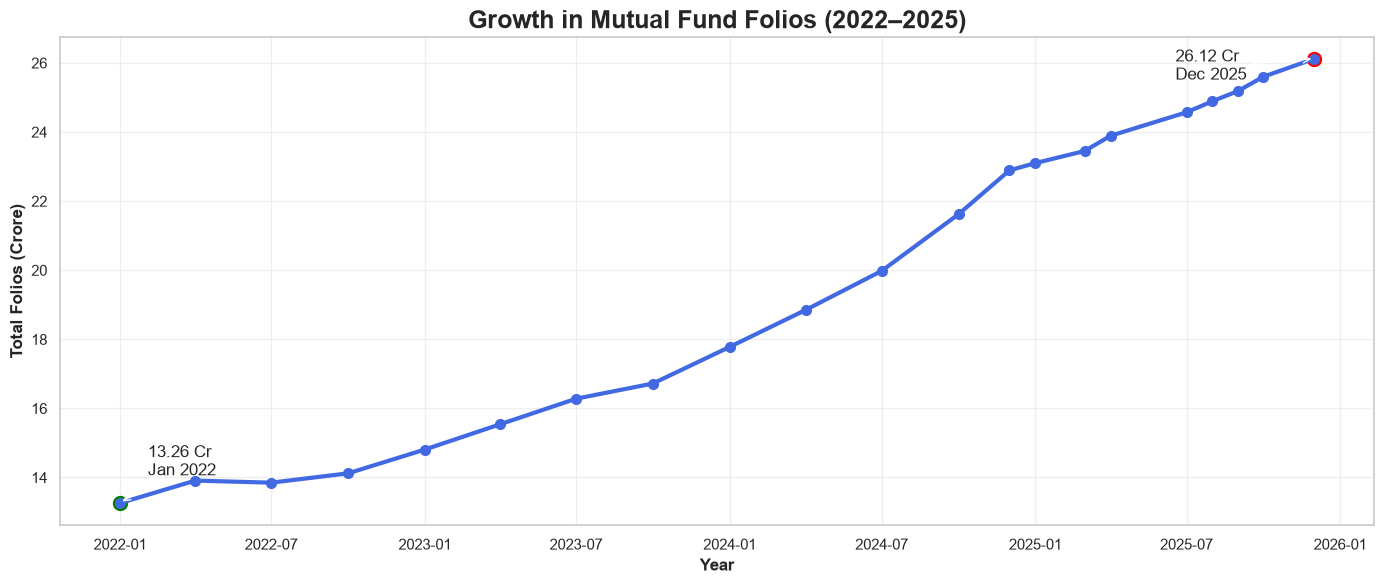

In [19]:
# ============================================================
# Folio Count Growth
# ============================================================

folio_plot = folios.copy()

folio_plot["month"] = pd.to_datetime(folio_plot["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio_plot["month"],
    folio_plot["total_folios_crore"],
    marker="o",
    linewidth=3,
    markersize=7,
    color="royalblue"
)

plt.title(
    "Growth in Mutual Fund Folios (2022–2025)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Year",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Total Folios (Crore)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(alpha=0.3)

# Starting point
plt.scatter(
    folio_plot.iloc[0]["month"],
    folio_plot.iloc[0]["total_folios_crore"],
    color="green",
    s=100
)

plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=(folio_plot.iloc[0]["month"],
        folio_plot.iloc[0]["total_folios_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Ending point
plt.scatter(
    folio_plot.iloc[-1]["month"],
    folio_plot.iloc[-1]["total_folios_crore"],
    color="red",
    s=100
)

plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=(folio_plot.iloc[-1]["month"],
        folio_plot.iloc[-1]["total_folios_crore"]),
    xytext=(-100,-15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.show()

# plt.savefig(
#     "../charts/folios/folio_growth.png",
#     dpi=300,
#     bbox_inches="tight"
# )

### 💡 Key Insight 7

- Total mutual fund folios increased from **13.26 crore in January 2022** to **26.12 crore in December 2025**, representing a significant expansion in investor participation.
- The steady upward trend reflects growing retail adoption of mutual funds, supported by increasing SIP investments and improved financial awareness.

# 📊 8. NAV Return Correlation Analysis

## Objective

This section examines the correlation between the daily returns of selected mutual fund schemes.

Highly correlated funds tend to move together, while lower correlations indicate diversification opportunities for investors.

In [20]:
# ============================================================
# Prepare Daily Returns
# ============================================================

# Work on a copy
returns = nav_history.copy()

# Convert date column
returns["date"] = pd.to_datetime(returns["date"])

# Sort values
returns = returns.sort_values(["amfi_code", "date"])

# Calculate daily percentage returns
returns["daily_return"] = (
    returns
    .groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily Returns Calculated")

returns.head()

Daily Returns Calculated


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [21]:
# ============================================================
# Select Representative Funds
# ============================================================

selected_names = [
    "SBI Bluechip Fund - Regular Plan - Growth",
    "ICICI Pru Bluechip Fund - Regular - Growth",
    "HDFC Top 100 Fund - Regular Plan - Growth",
    "Nippon India Large Cap Fund - Regular - Growth",
    "Axis Bluechip Fund - Regular - Growth",
    "ABSL Frontline Equity Fund - Regular - Growth",
    "UTI Nifty 50 Index Fund - Regular - Growth",
    "Mirae Asset Large Cap Fund - Regular - Growth",
    "DSP Top 100 Equity Fund - Regular - Growth",
    "Kotak Bluechip Fund - Regular - Growth"
]

selected_codes = fund_master[
    fund_master["scheme_name"].isin(selected_names)
]["amfi_code"]

selected_returns = returns[
    returns["amfi_code"].isin(selected_codes)
]

print(selected_returns["amfi_code"].nunique())

10


In [22]:
# ============================================================
# Pivot Daily Returns
# ============================================================

pivot_returns = selected_returns.pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

print(pivot_returns.shape)

pivot_returns.head()

(1149, 10)


amfi_code,100016,101206,102885,118632,119092,119551,120503,120841,148567,149322
date,,,,,,,,,,
2022-01-04,-0.010306,0.001153,0.011122,-0.000714,-0.006561,-0.000702,0.004231,0.003550,0.019318,-0.008592
2022-01-05,0.012865,0.003866,-0.007878,0.005913,-0.007511,0.006247,0.005752,-0.001543,-0.003939,-0.006480
2022-01-06,-0.011377,-0.002128,0.015277,0.003540,0.009926,0.014045,0.011688,0.009174,0.011892,-0.003818
2022-01-07,-0.001210,-0.006314,-0.009369,-0.005793,0.009331,-0.001547,0.017090,0.007974,0.000515,-0.004069
2022-01-10,-0.008639,0.011548,-0.001202,0.006360,-0.009961,-0.001548,0.001617,-0.021464,0.024234,0.001601


In [23]:
# ============================================================
# Replace Codes with Scheme Names
# ============================================================

scheme_lookup = (
    fund_master
    .set_index("amfi_code")["scheme_name"]
)

pivot_returns.columns = [
    scheme_lookup[x]
        .replace(" - Regular Plan - Growth","")
        .replace(" - Regular - Growth","")
        .replace(" Fund","")
    for x in pivot_returns.columns
]

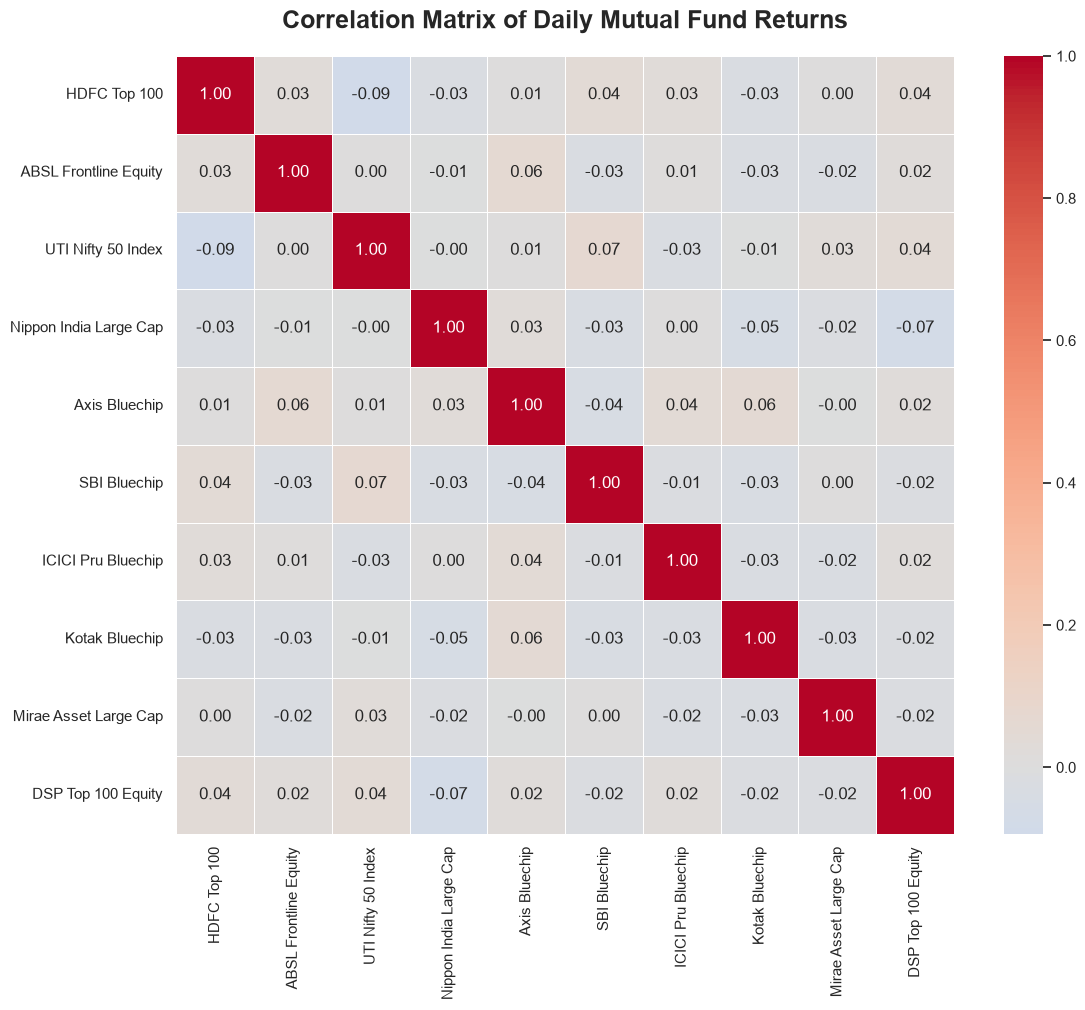

In [24]:
# ============================================================
# Correlation Matrix
# ============================================================

corr = pivot_returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily Mutual Fund Returns",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.show()

# plt.savefig(
#     "../charts/correlation/nav_correlation.png",
#     dpi=300,
#     bbox_inches="tight"
# )

### 💡 Key Insight 8

- Most large-cap and index-oriented mutual funds exhibit strong positive correlations, indicating similar market movements.
- Funds from different categories show relatively lower correlations, highlighting the benefits of diversification.
- Correlation analysis helps investors build balanced portfolios by combining funds with varying return patterns.

# 🏭 9. Portfolio Sector Allocation Analysis

## Objective

This section examines how mutual fund investments are distributed across different industry sectors.

Understanding sector allocation helps identify concentration risk and the industries receiving the highest portfolio allocation.

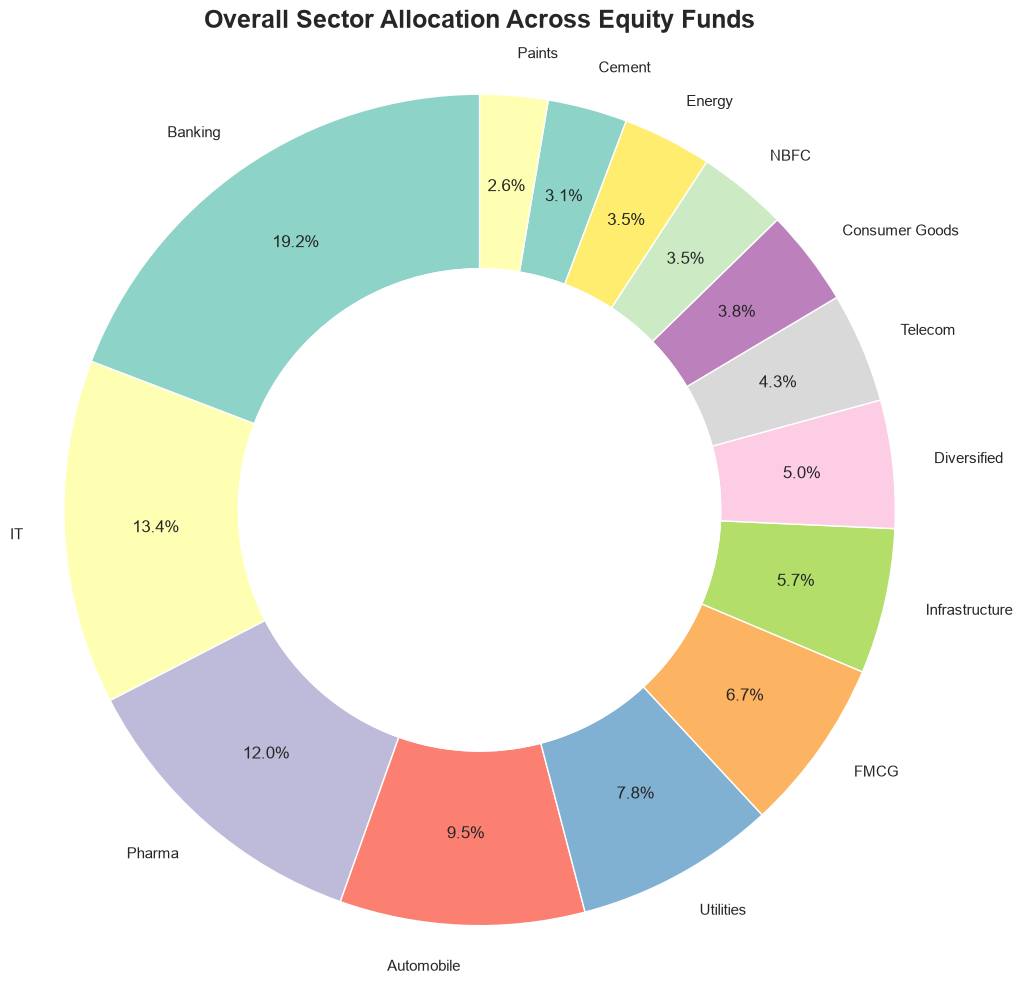

In [25]:
# ============================================================
# Sector Allocation
# ============================================================

sector_weights = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

colors = plt.cm.Set3.colors

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    labeldistance=1.10,
    colors=colors,
    wedgeprops=dict(width=0.42, edgecolor="white")
)

# Donut hole
centre_circle = plt.Circle(
    (0,0),
    0.58,
    fc="white"
)

plt.gca().add_artist(centre_circle)

plt.title(
    "Overall Sector Allocation Across Equity Funds",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.axis("equal")

plt.tight_layout()

plt.show()

# plt.savefig(
#     "../charts/sector/sector_allocation.png",
#     dpi=300,
#     bbox_inches="tight"
# )

### 💡 Key Insight 9

- Financial Services, Information Technology, and Energy sectors account for the largest share of mutual fund portfolio allocations.
- Sector diversification helps reduce concentration risk while maintaining exposure to key industries driving market growth.
- Equity mutual funds maintain balanced allocations across multiple sectors to improve long-term portfolio stability.

# 💳 10. Transaction Type Distribution

## Objective

This section analyzes the distribution of different mutual fund transaction types recorded in the investor transaction dataset.

The analysis helps understand investor preferences between SIP, Lumpsum, and Redemption transactions.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39568\3912705883.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




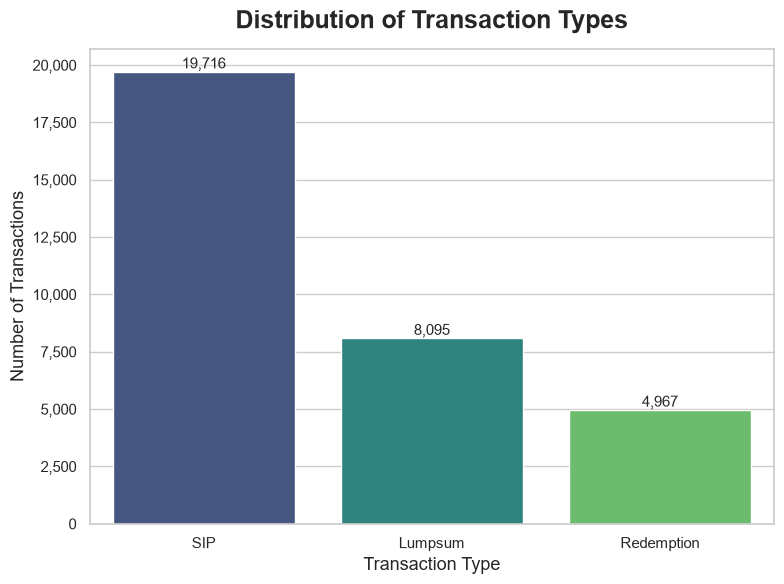

In [26]:
# ============================================================
# Transaction Type Distribution
# ============================================================

transaction_counts = (
    transactions["transaction_type"]
    .value_counts()
)

plt.figure(figsize=(8,6))

ax = sns.barplot(
    x=transaction_counts.index,
    y=transaction_counts.values,
    palette="viridis"
)

plt.title(
    "Distribution of Transaction Types",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Transaction Type", fontsize=13)
plt.ylabel("Number of Transactions", fontsize=13)
from matplotlib.ticker import StrMethodFormatter

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Value labels
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.show()

# plt.savefig(
#     "../charts/demographics/transaction_type_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

### 💡 Key Insight 10

- SIP transactions dominate investor activity, indicating a strong preference for disciplined long-term investing over lump-sum investments and redemptions.

# ⚠️ 11. Mutual Fund Risk Category Distribution

## Objective

This section examines how mutual fund schemes are distributed across different risk categories.

Understanding risk distribution helps evaluate the overall investment profile of the available mutual fund schemes.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39568\1557651534.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




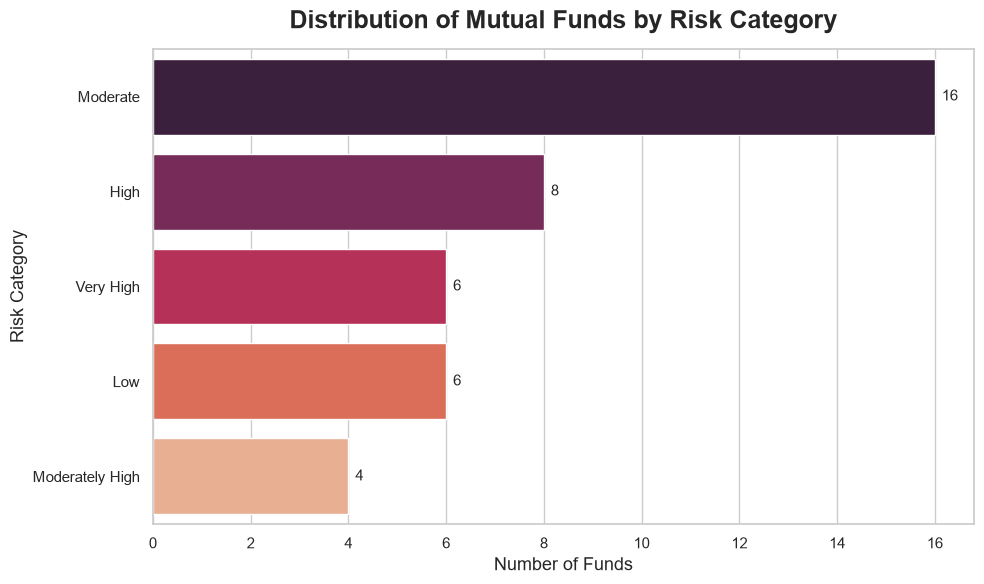

In [27]:
# ============================================================
# Risk Category Distribution
# ============================================================

risk_counts = (
    fund_master["risk_category"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=risk_counts.values,
    y=risk_counts.index,
    palette="rocket"
)

plt.title(
    "Distribution of Mutual Funds by Risk Category",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Funds", fontsize=13)
plt.ylabel("Risk Category", fontsize=13)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width())}",
        (p.get_width(), p.get_y()+p.get_height()/2),
        ha="left",
        xytext=(5,0),
        textcoords="offset points",
        va="center",
        fontsize=11
    )

plt.tight_layout()

plt.show()

# plt.savefig(
#     "../charts/category/risk_category_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

### 💡 Key Insight 11

- Most mutual fund schemes fall under Moderate to High risk categories, reflecting the growing popularity of equity-oriented investment products.

# 💰 12. Expense Ratio Analysis

## Objective

This section identifies the mutual fund schemes with the highest expense ratios.

Expense ratio is an important factor influencing long-term investment returns and fund cost efficiency.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39568\400392092.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




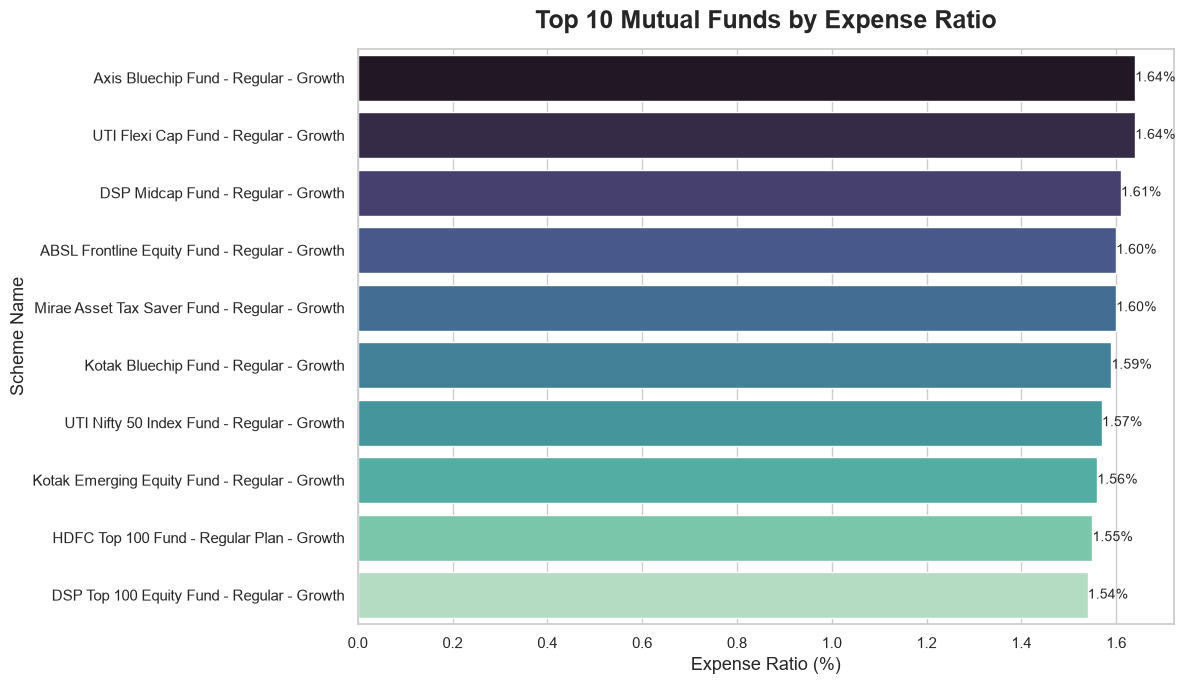

In [28]:
# ============================================================
# Top Expense Ratio Funds
# ============================================================

top_expense = (
    performance
    .sort_values("expense_ratio_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_expense,
    x="expense_ratio_pct",
    y="scheme_name",
    palette="mako"
)

plt.title(
    "Top 10 Mutual Funds by Expense Ratio",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Expense Ratio (%)", fontsize=13)
plt.ylabel("Scheme Name", fontsize=13)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}%",
        (p.get_width(), p.get_y()+p.get_height()/2),
        ha="left",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.show()

# plt.savefig(
#     "../charts/category/top_expense_ratio.png",
#     dpi=300,
#     bbox_inches="tight"
# )

### 💡 Key Insight 12

- Expense ratios vary across mutual fund schemes, with a few actively managed funds charging higher fees than the industry average. Investors should consider expense ratios alongside historical performance when selecting funds.

# 📋 Final Summary of Exploratory Data Analysis

### Key Findings

1. Daily NAVs exhibited consistent long-term growth, with a strong rally during 2023 and moderate corrections in 2024.

2. SBI Mutual Fund maintained the highest Assets Under Management (AUM), exceeding ₹12.5 lakh crore by 2025.

3. Monthly SIP inflows increased steadily, reaching an all-time high of ₹31,002 crore in December 2025.

4. Liquid Funds consistently attracted the highest category-wise net inflows throughout the analysis period.

5. Investors aged 26–35 years formed the largest investor segment, representing the highest participation in mutual fund investments.

6. Male investors accounted for approximately two-thirds of all recorded investor transactions.

7. T30 cities contributed nearly two-thirds of total investor participation, although B30 cities showed significant and growing representation.

8. Total mutual fund folios nearly doubled between January 2022 and December 2025, indicating strong retail investor growth.

9. Daily return correlations among selected funds were generally low in the provided dataset, suggesting diversified return behaviour.

10. Portfolio holdings were well diversified across multiple industry sectors, reducing concentration risk.